# Welcome to Lab: Justice ⚖️

We plan on continuing to explore simulation in Python this week. However, this time, we're going to simulate some **real-world events** that have actually happened in the past.  The goal is for you to see how we can use data science to think about issues of **equity** and **social justice**.  As usual, in addition to coding, we want you to get practice having **discussions about the data science** you're doing and think about how data science can be a useful tool that can help you in your future job and as a citizen.

**IMPORTANT NOTE**: In this lab, it's *very* important that you read through the text carefully. Understanding the context is crucial for success in `lab_justice` :)

A few tips to remember:

- **You are not alone on your journey in learning programming!**  You have your lab TA, your CAs, your lab group, and the professors (Prof. Wade and Prof. Karle), who are all here to help you out!
- If you find yourself stuck for more than a few minutes, ask a neighbor or course staff for help!  When you are giving help to your neighbor, explain the **idea and approach** to the problem without sharing the answer itself so they can have the same **<i>ah-hah</i>** moment!
- We are here to help you!  Don't feel embarrassed or shy to ask us for help!

Let's get started!

In [91]:
# Meet your CAs and TA if you haven't already!
# First name is enough, we'll know who they are! :)
ta_name = "Kunlun"
ca1_name = "Caroline"
ca2_name = "Emily"
ca3_name = ""


# Working with your group will be particularly important for discussion purposes in this week's lab!
#
# QOTD to Ask Your Group: "What is your favorite restaurant in Campustown/Champaign/Urbana?"
partner1_name = "Xinmeng"
partner1_netid = "xinmeng7"
partner1_restaurant = "ZhangLiang"

partner2_name = "Tianmen"
partner2_netid = "tianmen2"
partner2_restaurant = "Zhangliang"

partner3_name = ""
partner3_netid = ""
partner3_restaurant = ""

# Which lab section are you in? Record it below! It should start with a Y and have 
# 2 numbers after the Y. If you're unsure - ask your TA/CAs!
lab_section = "Y23"

<hr style="color: #DD3403;">

# Part 1: Jury Selection + Simulation

The 6th Amendment to the U.S. Constitution provides the right to an **“impartial jury”** in criminal prosecutions, but what exactly does this mean? The Supreme Court has said that juries must be drawn from a representative cross-section of the community. In other words, juries should be **randomly selected** from the eligible population. However, there are many instances in history where it doesn’t seem like this was the case.

Take for example, the case of Berghuis v. Smith.  In 1993, Smith (a Black man) was convicted of 2nd-degree murder by an **all-white** jury and sentenced to life in prison. The jury was selected from a panel of about 100 randomly selected people. Only 3 of them were Black and none of those 3 made it into the final 37 considered for Smith’s trial. The county population was approximately 8 percent Black at the time of the trial.  Remember, jury panels are supposed to be selected at random from the eligible population.

## Analysis: Your Initial Thoughts (Note that Question 1 requires a written response!)
**Because 8% of the eligible population was Black, 3 Black people on a panel of 100 might seem low.  Does this difference (8% vs. 3%) seem big to you? Do you think this could be due to chance? Discuss this with your group**

**Question 1:** Write a few sentences summarizing what your group members said during your discussion.  Did people think this difference could have been due to chance or not?


Overall, most of us agreed that while it could be random, the gap between the expected number (around 8) and the observed number (3) is large enough to raise questions about whether the selection process was truly fair and representative.

This case was appealed and sent to the Supreme Court.  Some people claimed that the overall percentage disparity (between 8% and 3%) was small and reflected no attempt to include or exclude "a specified number of Black people from the jury." They claimed this "small" difference could simply be due to chance.  Critics and Smith claimed that the system of jury selection caused the lack of fair and reasonable representation of Black people on the jury.

## Puzzle 1.1: Writing a Function

Let’s do a simulation in Python to understand what’s going on.  We will eventually write a simulation to show the expected distribution.  

Remember, from the case: we're trying to see if the difference between 8% and 3% is small and reflects no attempt to include or exclude "a specified number of Black people."  In other words, we want to **write a function** called `simulateJuryPanel` that **randomly samples 100 people from a population that is 8% Black**. The function should `return` the **number of Black people in the simulated jury**.  We can do this multiple times and see how rare it is to get 3 or fewer Black people in the jury.



In [68]:
import random
def simulateJuryPanel():
    black=0

    for i in range(100):
        if random.randint(1, 100) <= 8:
            black+=1
    return black
print (simulateJuryPanel())

12


### 🔬 Test Case Checkpoint 🔬

In [69]:
## == TEST CASES for Puzzle 1.1 ==
# - This read-only cell contains test cases for your previous cells.
# - If this cell runs without any error our output, you PASSED all test cases!
# - If this cell results in any errors, check you previous cell, make changes, and RE-RUN your code and then this cell.
assert callable(simulateJuryPanel), "You should have defined `simulateJuryPanel` as a function above."
assert isinstance(simulateJuryPanel(), int), "Your simulateJuryPanel() function should return an integer that represents the number of Black people on a jury from a population that is 8% Black."
test_juries = [simulateJuryPanel() for i in range(20)]
for jury in test_juries:
    assert(0 <= jury <= 100), "Your simulateJuryPanel() should only return integers between 0 and 100."
assert abs((sum(test_juries) / 20) - 8) <= 3, "Your calculations in simulateJuryPanel() are incorrect."
def check(list):
    return(all(i==list[0] for i in list))
assert(check(test_juries) == False), "Your simulation is returning the same number in every iteration. This is incorrect since we are randomly sampling from a population that is 8% Black."
assert round(sum(simulateJuryPanel() for i in range(1000))/1000) == 8, r"Make sure there is an 8% chance of picking a black person"
## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 1.2: Storing Simulation Results

Now that we have a working `simulateJuryPanel()` function, let's do a simulation and store the results in a DataFrame for analysis. Let’s do this simulation **10000 times**. Simulate choosing **10000 jury panels** by calling `simulateJuryPanel()` each time and store the number of Black people selected in every panel. Store these results in a DataFrame named `df`.

The variable or column in the DataFrame should be named `panel`.

In [70]:
import pandas as pd
import random
def simulateJuryPanel():
    black=0

    for i in range(100):
        if random.randint(1, 100) <= 8:
            black+=1
    return black
print (simulateJuryPanel())

data = []
for i in range(10000):
    data.append(simulateJuryPanel())


d = {"panel": data}  
df = pd.DataFrame(d)

7


### 🔬 Test Case Checkpoint 🔬

In [71]:
## == TEST CASES for Puzzle 1.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.
assert('df' in vars()), "Make sure your DataFrame is named `df`."
assert('panel' in df.columns.to_list()), "Make sure your simulations are stored in a column named `panel`."
assert(len(df) == 10000), "Your DataFrame is the wrong length. Perhaps you did not simulate 10000 times?"
assert(df['panel'].mean() < 8.5), "Your simulation isn't accurately simulating a randomly selected jury panel. You just created a function for this!"
assert(df['panel'].mean() > 7.5), "Your simulation isn't accurately simulating a randomly selected jury panel. You just created a function for this!"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 1.3: Visualization

Now, let's visualize the results of our simulation.  Since the number of Black jurors that are selected as part of the panel is a discrete variable that represents a category of results, it is best visualized with a **frequency bar chart** (histograms are best for continuous data).

Follow our DISCOVERY Guide: "Creating a Frequency Bar Chart from a DataFrame" to create a frequency bar chart.
- [DISCOVERY Guide: Creating a Frequency Bar Chart from a DataFrame](https://discovery.cs.illinois.edu/guides/Data-Visualization/value-counts-bar-chart/)

Create your frequency bar chart below. Make sure your plot has a descriptive title and axis labels!

10


<Axes: title={'center': 'Frequency of Number of Black Jurors in 10000 Simulated Panels'}, xlabel='panel'>

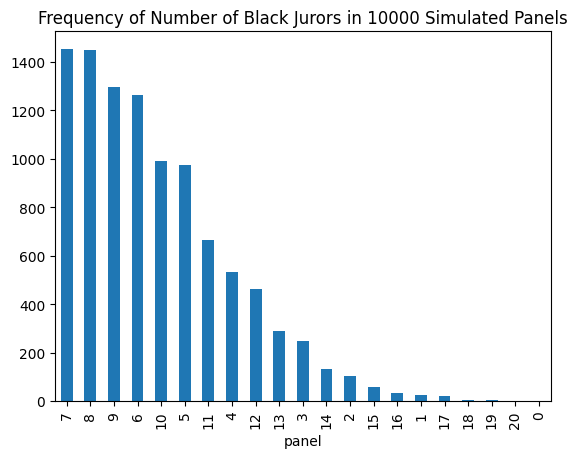

In [72]:
import pandas as pd
import random
def simulateJuryPanel():
    black=0

    for i in range(100):
        if random.randint(1, 100) <= 8:
            black+=1
    return black
print (simulateJuryPanel())

data = []
for i in range(10000):
    data.append(simulateJuryPanel())


d = {"panel": data}  
df = pd.DataFrame(d)

df["panel"].value_counts().plot.bar(title="Frequency of Number of Black Jurors in 10000 Simulated Panels")


## Puzzle 1.4: Observed and Expected Value

Using our simulation, we will observe and note any differences between the actual mean number of Black people in the juries and our expected value (which was 8).

Using the cell below, calculate the mean number of Black people in a jury from our `df` that you created from the simulation. Store your result in the variable `panel_mean` and then **display** the result.

In [73]:
panel_mean=df["panel"].mean()
panel_mean


np.float64(7.9264)

### 🔬 Test Case Checkpoint 🔬

In [74]:
## == TEST CASES for Puzzle 1.4 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.
assert('panel_mean' in vars()), "You should store your calculated result for the mean in a variable named `panel_mean`."
assert(panel_mean < 8.5), "You didn't calculate the mean correctly!"
assert(panel_mean> 7.5), "You didn't calculate the mean correctly!"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 1.5: Probability

Now that we've done simulation and some analysis, let's **estimate the probability** that we'll get **3 or less** Black members of the jury using `df`.  Store your results in a variable named `prob_3_or_less` and **display** the result. 

In [75]:
prob_3_or_less=(df["panel"] <= 3).sum() / len(df)
prob_3_or_less

np.float64(0.0375)

### 🔬 Test Case Checkpoint 🔬

In [76]:
## == TEST CASES for Puzzle 1.5 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.
assert('prob_3_or_less' in vars()), "Your probability should be stored in a variable named `prob_3_or_less`."
assert(prob_3_or_less < 0.05), "You didn't calculate the probability correctly!"
assert(prob_3_or_less > 0.025), "You didn't calculate the probability correctly!"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


<hr style="color: #DD3403;">

# Part 2: Names and Resumes

Our next problem comes from a study looking at the correlation between names and the job hiring process.  You can read the full study here if you’d like:
>[https://www.jstor.org/stable/3592802?seq=1](https://www.jstor.org/stable/3592802?seq=1)

Here’s a summary of some findings from their study:
- The researchers sent out a total of **4,870 resumes** to job postings in Chicago and Boston.
- The resumes that they sent were **identical**, except they changed the **names and email addresses** to have either a "white sounding" name or a "black sounding" name, according to the study.  
- There were an equal number of resumes with "white sounding" and "black sounding" names sent out (2,435 each).
- The resumes with "white sounding" names were called back for an interview **9.65% of the time (which corresponds to 235 resumes)** while the "black sounding" names were called back for an interview **6.45% of the time (which corresponds to 157 resumes)**.

**Assuming** that **any given resume** has about an **8.05% chance** of getting a callback **(the average callback rate observed across all resumes)**, let’s simulate this study.

Since the content of the resumes are identical, we should expect to get an **equal number of callbacks** for both types of names.  In other words, picking the callbacks should be like **random sampling**.

We've simulated the data in `resumes.csv` and wrote part of a simulation function to randomly sample 8.05% of the **4,870** resumes 10,000 times. You will load in the data and complete the simulation below.

## Puzzle 2.1: Load in the Data

In the same folder as this lab, you have a **dataset of resumes** named `resumes.csv` that contains **4,870 rows** - the **same number** of resumes used in the study.

Half are 0s (representing resumes with "white sounding" names) and the other half are 1s (representing resumes with "black sounding" names).

Load this data into a DataFrame named `df_resumes`:

In [77]:
import pandas as pd
df_resumes=pd.read_csv("resumes.csv")
df


,panel
0,9
1,8
2,8
3,5
4,8
...,...
9995,6
9996,14
9997,13
9998,8


### 🔬 Test Case Checkpoint 🔬

In [78]:
## == TEST CASES for Puzzle 2.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.
assert('df_resumes' in vars()), "Your DataFrame of resumes should be named `df_resumes`."
assert((len(df_resumes) == 4870) & ('Resumes' in df_resumes.columns.to_list())), "This isn't the dataset we are looking for. Make sure you are loading the resumes.csv file."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 2.2: Sampling from the DataFrame & Finding the Number of Resumes that Received Callbacks

Create a new DataFrame called `df_sample` that contains a random sample of **392** (235 + 157) resumes from `df_resumes`.  This sample represents all of the resumes that received a call back if the resumes **were truly randomly selected without bias**.

Using your `df_sample` (the sample of all people who received callbacks), calculate and display two values in the next two cells:

- `callbacks_black_sounding`, the **number of callbacks** received by people with Black-sounding names.
- `callbacks_white_sounding`, the **number of callbacks** received by people with White-sounding names.

Make sure to **display your results.**

In [79]:
# Randomly sample 392 rows from the dataframe

df_sample=df_resumes.sample(n=392)
df_sample


,Resumes
1229,0
1146,0
4352,1
610,0
652,0
...,...
2798,1
2012,0
1524,0
2536,1


In [80]:
# Calculate and display callbacks_black_sounding
callbacks_black_sounding= int((df_sample["Resumes"] == 1).sum())
callbacks_black_sounding


211

In [81]:
# Calculate and display callbacks_white_sounding
callbacks_white_sounding= int((df_sample["Resumes"] == 0).sum())
callbacks_white_sounding

181

### 🔬 Test Case Checkpoint 🔬

In [82]:
## == TEST CASES for Puzzle 2.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.
assert ("df_sample" in vars()), "Make sure your dataframe is named `df_sample`."
assert (abs(len(df_resumes) * 0.0805 - len(df_sample)) <= 1), "Your parameter in .sample() is incorrect."
assert (type(callbacks_black_sounding)==int and type(callbacks_white_sounding)==int), "Make sure `callbacks_black_sounding` and `callbacks_white_sounding` are numbers, not dataframes"
assert (callbacks_black_sounding + callbacks_white_sounding == 392), "`callbacks_black_sounding` and `callbacks_white_sounding` should add to 392"

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 2.3: Build a Simulation

Using your code from Puzzle 2.2 as the real-world events, write a simulation that simulates randomly selecting a sample of 392 from df_resumes 10,000 times and recording how many `callbacks_black_sounding` and `callbacks_white_sounding` names you got in each iteration.

In recording each observation, you only need to record the `callbacks_black_sounding` and `callbacks_white_sounding` variables. In other words, your dictionary `d` will be:

> ```py
> d = { "callbacks_black_sounding": callbacks_black_sounding, "callbacks_white_sounding": callbacks_white_sounding }
> ```

Store the result of 10,000 simulations in a DataFrame called `df_simulation`:

In [83]:
# Complete a simulation 10,000 times:
import pandas as pd
data=[]
for i in range(10000):
    df_sample = df_resumes.sample(n=392)
    callbacks_black_sounding = int((df_sample["Resumes"] == 1).sum())
    callbacks_white_sounding = int((df_sample["Resumes"] == 0).sum())
    d = {"callbacks_black_sounding": callbacks_black_sounding, "callbacks_white_sounding": callbacks_white_sounding}
    data.append(d)
df_simulation=pd.DataFrame(data)
df_simulation
    

,callbacks_black_sounding,callbacks_white_sounding
0,188,204
1,181,211
2,189,203
3,196,196
4,178,214
...,...,...
9995,203,189
9996,207,185
9997,207,185
9998,177,215


In [84]:
# Display the result of the simulation:
df_simulation

,callbacks_black_sounding,callbacks_white_sounding
0,188,204
1,181,211
2,189,203
3,196,196
4,178,214
...,...,...
9995,203,189
9996,207,185
9997,207,185
9998,177,215


### 🔬 Test Case Checkpoint 🔬

In [85]:
## == TEST CASES for Puzzle 2.3 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.

assert("df_simulation" in vars()), "Make sure your resulting dataframe is named `df_simulation`."
assert("callbacks_black_sounding" in df_simulation), "You've labeled your `callbacks_black_sounding` column incorrectly."
assert("callbacks_white_sounding" in df_simulation), "You've labeled your `callbacks_white_sounding` column incorrectly."

assert( len(df_simulation[ df_simulation["callbacks_white_sounding"] > df_simulation["callbacks_black_sounding"] ]) > 0 )
assert( len(df_simulation[ df_simulation["callbacks_white_sounding"] < df_simulation["callbacks_black_sounding"] ]) > 0 )

assert( df_simulation["callbacks_white_sounding"].sum() > 1900000 ), "Make sure your for loop runs 10000 times."
assert( df_simulation["callbacks_black_sounding"].sum() > 1900000 ), "Make sure your for loop runs 10000 times."

assert( df_simulation["callbacks_white_sounding"].sum() < 2300000 ), "Make sure your for loop runs 10000 times."
assert( df_simulation["callbacks_black_sounding"].sum() < 2300000 ), "Make sure your for loop runs 10000 times."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 2.4: Calculate the Size of the Difference Between Groups

Add a new column to your simulation DataFrame called `callbacks_difference` that is the magnitude of the absolute difference in number of callbacks between the two groups in your simulation.  Each row is the difference in the number of callbacks if resumes were randomly selected without bias.

*Hint: Use the function `abs()` to get the absolute value of a number, or in this case, the absolute value of the difference between the two groups.*


In [86]:
# Add the new column "callbacks_difference":
df_simulation["callbacks_difference"] = abs(df_simulation["callbacks_black_sounding"] - df_simulation["callbacks_white_sounding"])
df_simulation

,callbacks_black_sounding,callbacks_white_sounding,callbacks_difference
0,188,204,16
1,181,211,30
2,189,203,14
3,196,196,0
4,178,214,36
...,...,...,...
9995,203,189,14
9996,207,185,22
9997,207,185,22
9998,177,215,38


### 🔬 Test Case Checkpoint 🔬

In [87]:
## == TEST CASES for Puzzle 2.4 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs with the success message as your output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, & RE-RUN your code & then this cell.
assert("callbacks_difference" in df_simulation), "Make sure your new column is called `callbacks_difference`."
assert( (abs(df_simulation["callbacks_black_sounding"] - df_simulation["callbacks_white_sounding"]) - df_simulation["callbacks_difference"]).sum() == 0 ), "Make sure you are taking the absolute value of the difference using `abs()."
assert(df_simulation["callbacks_difference"].mean() < 40), "Make sure you are taking the absolute value of the difference using `abs()."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


## Puzzle 2.5: Visualization Again!

Now, let's visualize the results of our simulation using a **histogram**.

Create your histogram with 20 bins below showing the differences in callbacks. Make sure your plot has a descriptive title and axis labels!

<Axes: title={'center': 'Distribution of Differences in Callbacks Between Black and White Names'}, xlabel='Absolute Difference in Callbacks', ylabel='Frequency'>

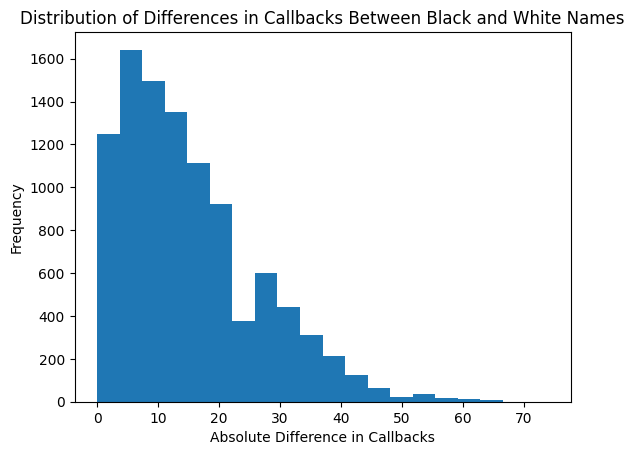

In [88]:
df_simulation["callbacks_difference"].plot.hist(bins=20,title="Distribution of Differences in Callbacks Between Black and White Names",xlabel="Absolute Difference in Callbacks",ylabel="Frequency")


## Puzzle 2.6: Finding the Samples with a Larger Impact

In the study presented, the Black-sounding names were called back only 6.45% of the time and the white-sounding names were called back 9.65% of the time.  Of all the 4,870 resumes, the Black-sounding names were called back 157 times and the white-sounding names were called back 235 times. In other words, there was a **difference of 78 callbacks** between the two groups.

Using your `df_simulation` DataFrame, select all of the rows with **78 or more callbacks** in the column `callbacks_difference`. **Display** the resulting dataframe. 

In [89]:
large_difference = df_simulation[df_simulation["callbacks_difference"] >= 78]
large_difference


,callbacks_black_sounding,callbacks_white_sounding,callbacks_difference


Now, using your code from above, calculate the **proportion** of simulations that had a difference of **78 or more callbacks** in the cell below. **Display** the result. 

In [90]:
proportion=len(large_difference) / len(df_simulation)
proportion

0.0

## Analysis: Final Reflection on Parts 1 and 2

**Question 2:** Interpret what the probability you found in Puzzle 1.5 means. Given this probability, do you think the outcome that was observed in our case was due to chance? Explain why or why not.

**Question 3:** Interpret what the proportion you found in Puzzle 2.6 means. Given this proportion, do you think the outcome that was observed in this study was due to chance? Explain why or why not.

The probability we found in Puzzle 1.5 tells us how likely it is to randomly get 3 or fewer Black jurors out of 100 because this probability is very small.so that the observation that there are no black people in the actual jury is likely not accidental but rather influenced by systemic factors
The proportion from Puzzle 2.6 tells us how often we would see a difference of 78 or more callbacks just by random chance. This is because this proportion is very small,

<hr style="color: #DD3403;">

## Submission

You're almost done!  All you need to do is to commit your lab to GitHub:

1.  ⚠️ **Make sure to save your work.** ⚠️ To do this, go to **File => Save All**

2.  After you have saved, exit this notebook & follow the Canvas instructions to commit this lab to your Git repository!

3. Your TA will grade your submission & provide you feedback after the lab is due. :)